In [ ]:
# Analyzing the Relationship between Income and Savings Behavior using ML

In [ ]:
# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# loading dataset
df = pd.read_csv('Findex_Pakistan_2025_Improved.csv')
print('Dataset shape:', df.shape)
df.head()

Dataset shape: (1880, 9)


,inc_q,saved,age,female,educ,urbanicity,emp_in,inc_educ,age_group
0,5,0,21,1,2,2,1,10,1
1,5,0,49,1,2,1,1,10,4
2,4,1,69,1,2,2,1,8,5
3,2,0,28,2,2,2,2,4,2
4,2,0,24,1,1,1,1,2,1


In [ ]:
# checking shape and basic info
print('Shape:', df.shape)
print()
df.info()

Shape: (1880, 9)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1880 entries, 0 to 1879
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   inc_q       1880 non-null   int64
 1   saved       1880 non-null   int64
 2   age         1880 non-null   int64
 3   female      1880 non-null   int64
 4   educ        1880 non-null   int64
 5   urbanicity  1880 non-null   int64
 6   emp_in      1880 non-null   int64
 7   inc_educ    1880 non-null   int64
 8   age_group   1880 non-null   int64
dtypes: int64(9)
memory usage: 132.3 KB


In [ ]:
# checking for missing values
print(df.isnull().sum())

inc_q         0
saved         0
age           0
female        0
educ          0
urbanicity    0
emp_in        0
inc_educ      0
age_group     0
dtype: int64


In [39]:
# dropping rows with missing values
df = df.dropna()
print("Shape after dropping nulls:", df.shape)

Shape after dropping nulls: (1880, 13)


In [40]:
# feature engineering
# interaction term: combined effect of income and education on savings
df['inc_educ'] = df['inc_q'] * df['educ']

# age grouped into decades based on life cycle savings theory
df['age_group'] = pd.cut(df['age'], bins=[14, 24, 34, 44, 54, 100],
                          labels=[1, 2, 3, 4, 5]).astype(int)

print("Features after engineering:")
print(df[['inc_educ', 'age_group']].head(10))# basic statistics
df.describe()

Features after engineering:
   inc_educ  age_group
0        10          1
1        10          4
2         8          5
3         4          2
4         2          1
5         3          2
6        15          5
7        12          5
8        12          5
9         2          5


,inc_q,saved,age,female,educ,urbanicity,emp_in,inc_educ,age_group,cluster
count,1880.000000,1880.000000,1880.000000,1880.000000,1880.000000,1880.000000,1880.000000,1880.000000,1880.000000,1880.000000
mean,3.513830,0.625532,47.461702,1.480319,2.042021,1.469681,1.520213,7.194681,3.523404,0.846809
std,1.366683,0.484114,18.151383,0.499745,0.815523,0.499213,0.499724,4.206786,1.454832,0.756691
min,1.000000,0.000000,15.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,2.000000,0.000000,32.000000,1.000000,1.000000,1.000000,1.000000,4.000000,2.000000,0.000000
50%,4.000000,1.000000,48.000000,1.000000,2.000000,1.000000,2.000000,6.000000,4.000000,1.000000
75%,5.000000,1.000000,62.000000,2.000000,3.000000,2.000000,2.000000,10.000000,5.000000,1.000000
max,5.000000,1.000000,79.000000,2.000000,3.000000,2.000000,2.000000,15.000000,5.000000,2.000000


In [ ]:
# checking value counts for key columns
for col in ['inc_q', 'saved', 'female', 'educ', 'urbanicity', 'emp_in', 'age_group']:
    print(f'\n{col}:')
    print(df[col].value_counts().sort_index())


inc_q:
inc_q
1    210
2    289
3    307
4    473
5    601
Name: count, dtype: int64

saved:
saved
0     704
1    1176
Name: count, dtype: int64

female:
female
1    977
2    903
Name: count, dtype: int64

educ:
educ
1    587
2    627
3    666
Name: count, dtype: int64

urbanicity:
urbanicity
1    997
2    883
Name: count, dtype: int64

emp_in:
emp_in
1    902
2    978
Name: count, dtype: int64

age_group:
age_group
1    235
2    313
3    301
4    295
5    736
Name: count, dtype: int64


In [ ]:
# ================================
# EXPLORATORY DATA ANALYSIS (EDA)
# ================================

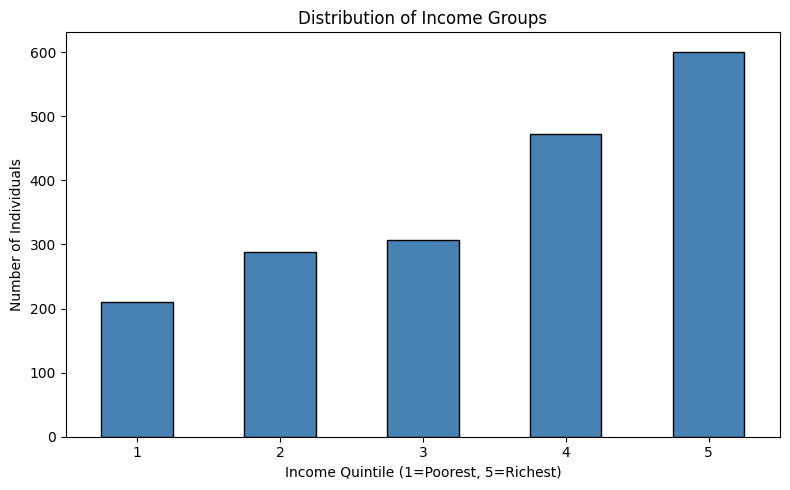

In [ ]:
# distribution of income groups
plt.figure(figsize=(8, 5))
df['inc_q'].value_counts().sort_index().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Distribution of Income Groups')
plt.xlabel('Income Quintile (1=Poorest, 5=Richest)')
plt.ylabel('Number of Individuals')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

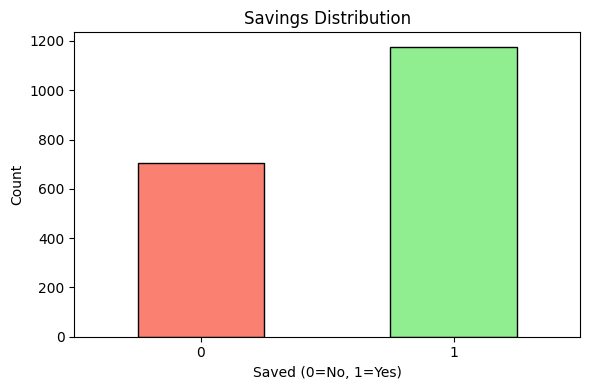

Class distribution:
saved
1    1176
0     704
Name: count, dtype: int64


In [ ]:
# class distribution of savings
plt.figure(figsize=(6, 4))
df['saved'].value_counts().sort_index().plot(kind='bar', color=['salmon', 'lightgreen'], edgecolor='black')
plt.title('Savings Distribution')
plt.xlabel('Saved (0=No, 1=Yes)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print('Class distribution:')
print(df['saved'].value_counts())

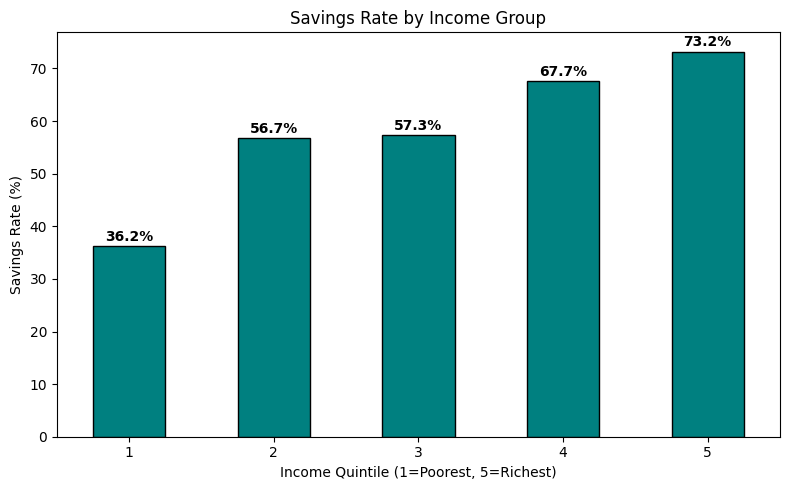

In [ ]:
# savings rate by income group
savings_by_income = df.groupby('inc_q')['saved'].mean() * 100
plt.figure(figsize=(8, 5))
savings_by_income.plot(kind='bar', color='teal', edgecolor='black')
plt.title('Savings Rate by Income Group')
plt.xlabel('Income Quintile (1=Poorest, 5=Richest)')
plt.ylabel('Savings Rate (%)')
plt.xticks(rotation=0)
for i, v in enumerate(savings_by_income):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

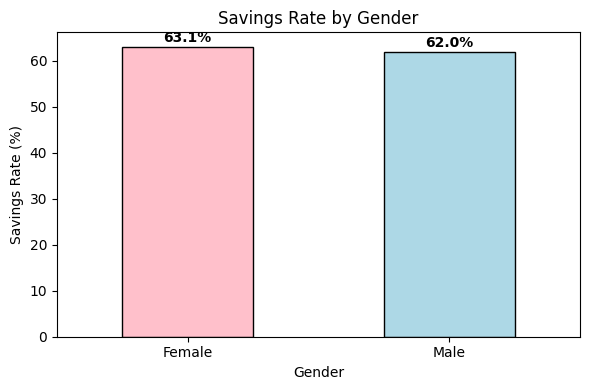

In [ ]:
# savings rate by gender
gender_labels = {1: 'Female', 2: 'Male'}
df['gender_label'] = df['female'].map(gender_labels)
savings_by_gender = df.groupby('gender_label')['saved'].mean() * 100
plt.figure(figsize=(6, 4))
savings_by_gender.plot(kind='bar', color=['pink', 'lightblue'], edgecolor='black')
plt.title('Savings Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Savings Rate (%)')
plt.xticks(rotation=0)
for i, v in enumerate(savings_by_gender):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

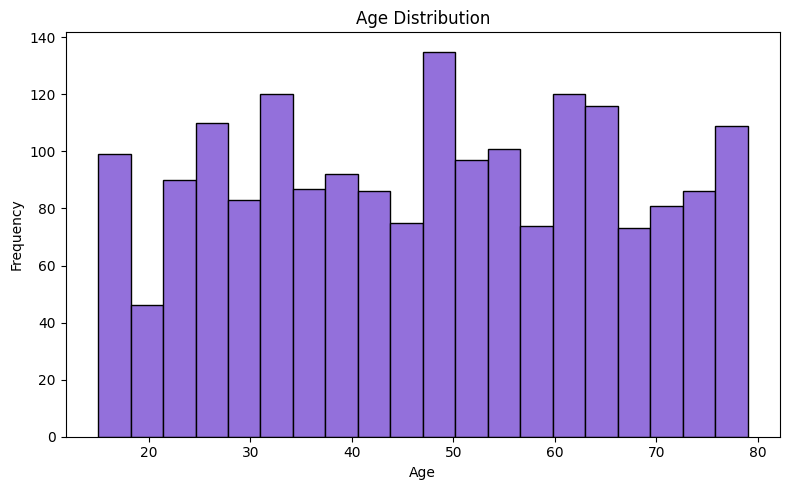

In [ ]:
# age distribution
plt.figure(figsize=(8, 5))
plt.hist(df['age'], bins=20, color='mediumpurple', edgecolor='black')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

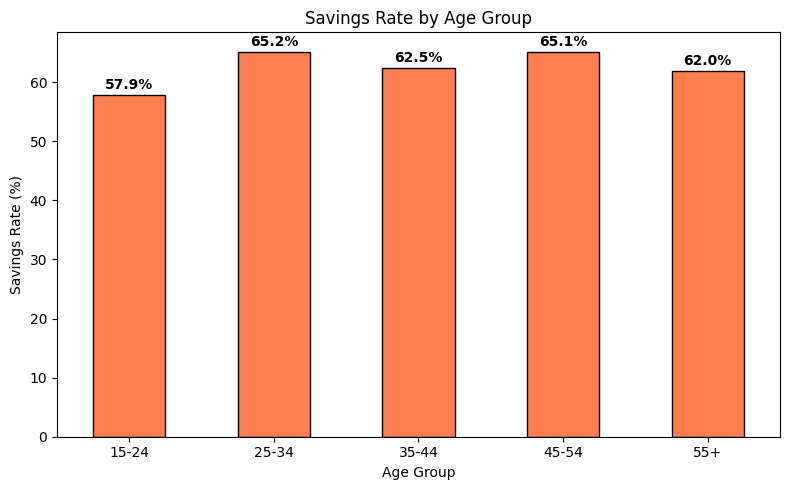

In [ ]:
# savings rate by age group
age_labels = {1: '15-24', 2: '25-34', 3: '35-44', 4: '45-54', 5: '55+'}
df['age_group_label'] = df['age_group'].map(age_labels)
savings_by_age = df.groupby('age_group_label')['saved'].mean() * 100
savings_by_age = savings_by_age.reindex(['15-24', '25-34', '35-44', '45-54', '55+'])
plt.figure(figsize=(8, 5))
savings_by_age.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Savings Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Savings Rate (%)')
plt.xticks(rotation=0)
for i, v in enumerate(savings_by_age):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

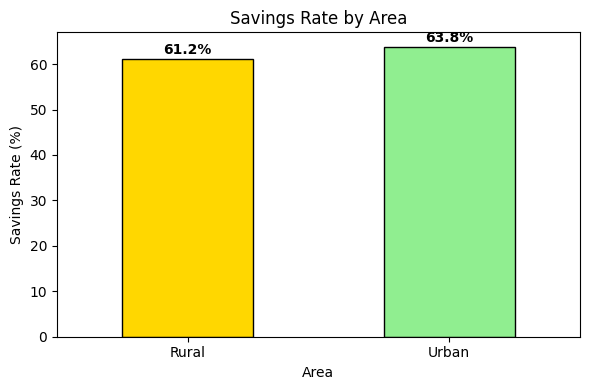

In [ ]:
# savings rate by area
urban_labels = {1: 'Urban', 2: 'Rural'}
df['area'] = df['urbanicity'].map(urban_labels)
savings_by_area = df.groupby('area')['saved'].mean() * 100
plt.figure(figsize=(6, 4))
savings_by_area.plot(kind='bar', color=['gold', 'lightgreen'], edgecolor='black')
plt.title('Savings Rate by Area')
plt.xlabel('Area')
plt.ylabel('Savings Rate (%)')
plt.xticks(rotation=0)
for i, v in enumerate(savings_by_area):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

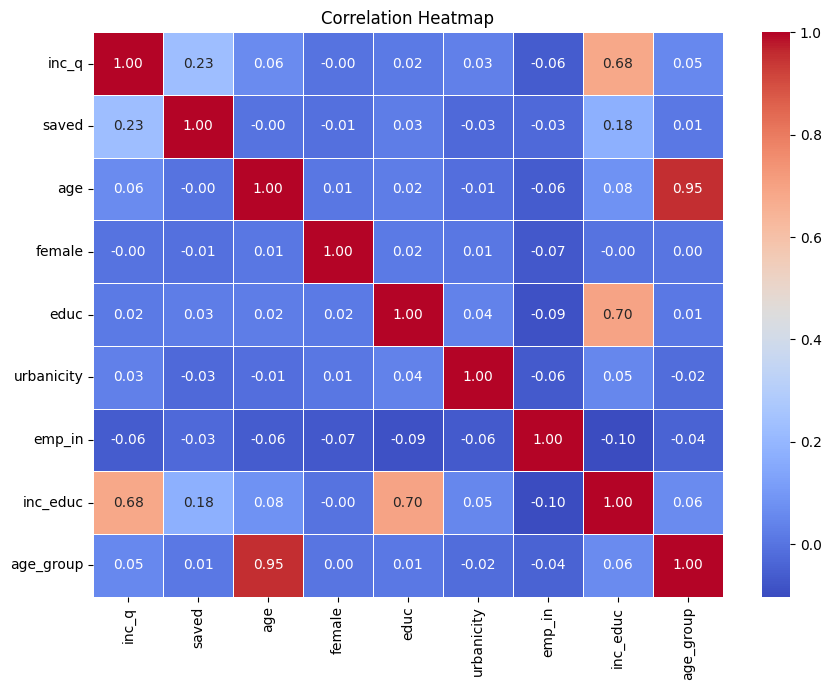

In [ ]:
# correlation heatmap
plt.figure(figsize=(9, 7))
corr = df[['inc_q', 'saved', 'age', 'female', 'educ', 'urbanicity', 'emp_in', 'inc_educ', 'age_group']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [ ]:
# ================================
# MACHINE LEARNING MODELS
# ================================

In [41]:
# model selection: comparing Logistic Regression vs Gradient Boosting
from sklearn.linear_model import LogisticRegression

X_temp = df[['inc_q', 'age', 'female', 'educ', 'urbanicity', 'emp_in', 'inc_educ', 'age_group']]
y_temp = df['saved']

X_tr, X_te, y_tr, y_te = train_test_split(X_temp, y_temp, test_size=0.2,
                                            random_state=42, stratify=y_temp)

# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_tr, y_tr)
lr_pred = lr.predict(X_te)

# Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=200, max_depth=6,
                                 learning_rate=0.1, random_state=42)
gb.fit(X_tr, y_tr)
gb_pred = gb.predict(X_te)

print("=== Model Comparison ===")
print(f"{'Metric':<12} {'Logistic Reg':>15} {'Gradient Boost':>16}")
print("-" * 45)
for metric, fn in [('Accuracy', accuracy_score), ('Precision', precision_score),
                   ('Recall', recall_score), ('F1-Score', f1_score)]:
    lr_score = fn(y_te, lr_pred)
    gb_score = fn(y_te, gb_pred)
    print(f"{metric:<12} {lr_score:>15.4f} {gb_score:>16.4f}")

print("\nGradient Boosting selected as final model:")
print("- Captures non-linear relationships and variable interactions")
print("- Higher F1-score, better recall on minority class")
print("- Sequential tree building corrects errors of previous trees")

=== Model Comparison ===
Metric          Logistic Reg   Gradient Boost
---------------------------------------------
Accuracy              0.6330           0.8777
Precision             0.6550           0.8363
Recall                0.8723           1.0000
F1-Score              0.7482           0.9109

Gradient Boosting selected as final model:
- Captures non-linear relationships and variable interactions
- Higher F1-score, better recall on minority class
- Sequential tree building corrects errors of previous trees


In [ ]:
# preparing features and target
X = df[['inc_q', 'age', 'female', 'educ', 'urbanicity', 'emp_in', 'inc_educ', 'age_group']]
y = df['saved']

# stratified 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Training set size:', X_train.shape[0])
print('Testing set size: ', X_test.shape[0])

Training set size: 1504
Testing set size:  376


In [ ]:
# Gradient Boosting Classifier
model = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)
model.fit(X_train, y_train)

# predictions
y_pred = model.predict(X_test)

In [ ]:
# model evaluation
print('=== Gradient Boosting Results ===')
print(f'Accuracy:  {accuracy_score(y_test, y_pred):.4f}')
print(f'Precision: {precision_score(y_test, y_pred):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred):.4f}')
print(f'F1-Score:  {f1_score(y_test, y_pred):.4f}')

=== Gradient Boosting Results ===
Accuracy:  0.8777
Precision: 0.8363
Recall:    1.0000
F1-Score:  0.9109


In [ ]:
# classification report
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Not Saved', 'Saved']))


Classification Report:
              precision    recall  f1-score   support

   Not Saved       1.00      0.67      0.81       141
       Saved       0.84      1.00      0.91       235

    accuracy                           0.88       376
   macro avg       0.92      0.84      0.86       376
weighted avg       0.90      0.88      0.87       376



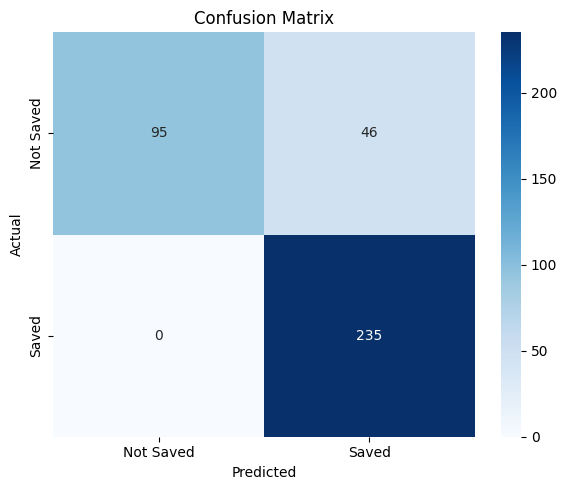

In [ ]:
# confusion matrix
cm_result = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_result, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Saved', 'Saved'],
            yticklabels=['Not Saved', 'Saved'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [ ]:
# 5-fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X, y, cv=cv, scoring='f1')

print('=== 5-Fold Cross-Validation F1 Scores ===')
for i, score in enumerate(cv_scores):
    print(f'  Fold {i+1}: {score:.4f}')
print(f'\nMean F1: {cv_scores.mean():.4f}')
print(f'Std Dev: {cv_scores.std():.4f}')

=== 5-Fold Cross-Validation F1 Scores ===
  Fold 1: 0.8923
  Fold 2: 0.9004
  Fold 3: 0.9006
  Fold 4: 0.9091
  Fold 5: 0.8945

Mean F1: 0.8994
Std Dev: 0.0058


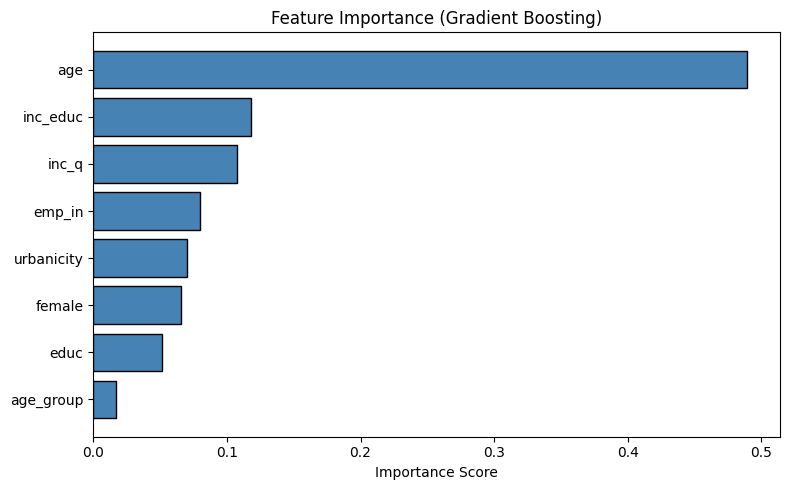

      Feature  Importance
1         age    0.489379
6    inc_educ    0.117679
0       inc_q    0.107858
5      emp_in    0.080176
4  urbanicity    0.070445
2      female    0.065873
3        educ    0.051484
7   age_group    0.017106


In [ ]:
# feature importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(feature_importance['Feature'], feature_importance['Importance'],
         color='steelblue', edgecolor='black')
plt.title('Feature Importance (Gradient Boosting)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print(feature_importance.sort_values('Importance', ascending=False))

In [ ]:
# ================================
# K-MEANS CLUSTERING
# ================================

In [ ]:
# preparing data for clustering
cluster_data = df[['inc_q', 'saved']].copy()

# scaling the data
scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_data)

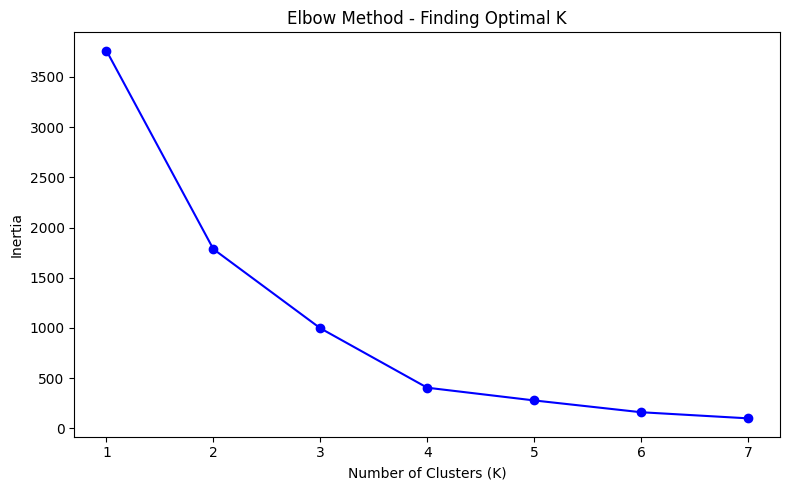

In [ ]:
# finding optimal number of clusters using elbow method
inertia = []
k_range = range(1, 8)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(cluster_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, 'bo-')
plt.title('Elbow Method - Finding Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.tight_layout()
plt.show()

In [ ]:
# applying K-Means with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(cluster_scaled)

In [ ]:
# cluster distribution
print('Cluster distribution:')
print(df['cluster'].value_counts().sort_index())

Cluster distribution:
cluster
0    704
1    760
2    416
Name: count, dtype: int64


In [ ]:
# cluster analysis - mean values per cluster
cluster_analysis = df.groupby('cluster')[['inc_q', 'saved', 'age']].mean()
print('\nCluster Analysis (Mean Values):')
print(cluster_analysis)


Cluster Analysis (Mean Values):
            inc_q  saved        age
cluster                            
0        3.116477    0.0  47.528409
1        4.578947    1.0  48.910526
2        2.240385    1.0  44.701923


In [ ]:
# cluster characteristics
for i in range(3):
    cluster_df = df[df['cluster'] == i]
    avg_income = cluster_df['inc_q'].mean()
    avg_saved  = cluster_df['saved'].mean()
    print(f'Cluster {i}: Avg Income Quintile = {avg_income:.2f}, Savings Rate = {avg_saved*100:.1f}%')

Cluster 0: Avg Income Quintile = 3.12, Savings Rate = 0.0%
Cluster 1: Avg Income Quintile = 4.58, Savings Rate = 100.0%
Cluster 2: Avg Income Quintile = 2.24, Savings Rate = 100.0%


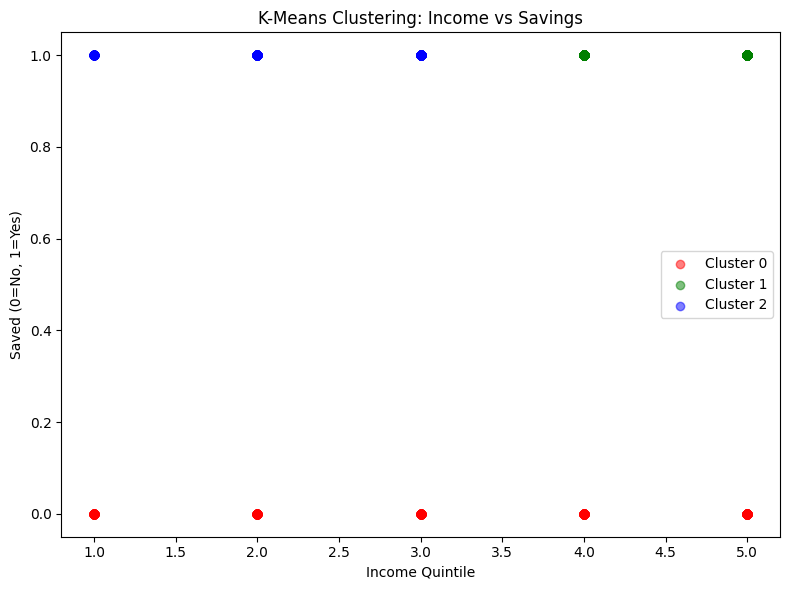

In [ ]:
# cluster visualization
plt.figure(figsize=(8, 6))
colors = ['red', 'green', 'blue']
for i in range(3):
    cluster_df = df[df['cluster'] == i]
    plt.scatter(cluster_df['inc_q'], cluster_df['saved'],
                c=colors[i], label=f'Cluster {i}', alpha=0.5)
plt.title('K-Means Clustering: Income vs Savings')
plt.xlabel('Income Quintile')
plt.ylabel('Saved (0=No, 1=Yes)')
plt.legend()
plt.tight_layout()
plt.show()

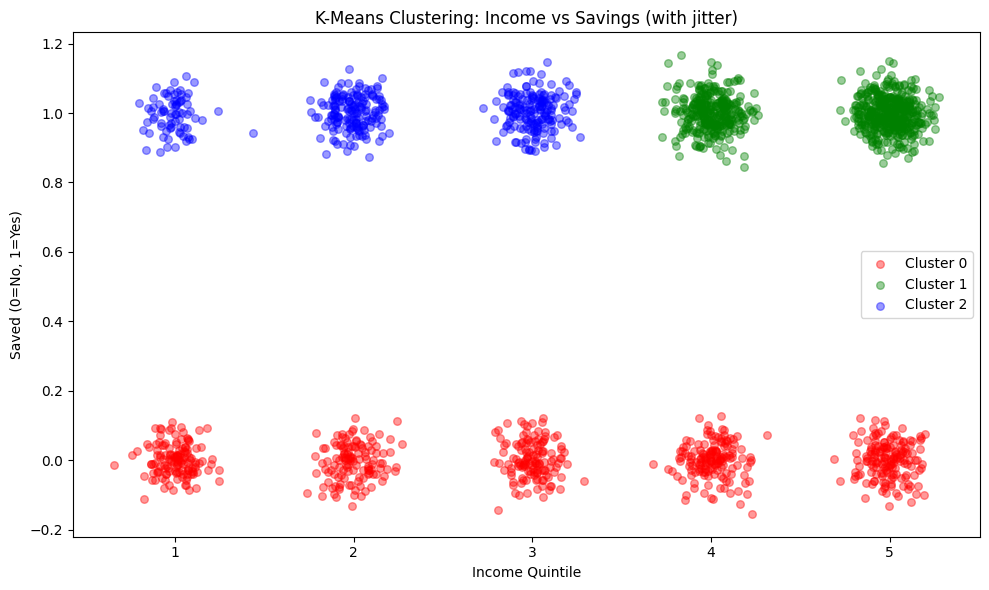

In [ ]:
# cluster visualization with jitter for better visibility
plt.figure(figsize=(10, 6))
for i in range(3):
    cluster_df = df[df['cluster'] == i]
    jitter_x = cluster_df['inc_q'] + np.random.normal(0, 0.1, len(cluster_df))
    jitter_y = cluster_df['saved'] + np.random.normal(0, 0.05, len(cluster_df))
    plt.scatter(jitter_x, jitter_y, c=colors[i], label=f'Cluster {i}', alpha=0.4, s=30)
plt.title('K-Means Clustering: Income vs Savings (with jitter)')
plt.xlabel('Income Quintile')
plt.ylabel('Saved (0=No, 1=Yes)')
plt.legend()
plt.tight_layout()
plt.show()

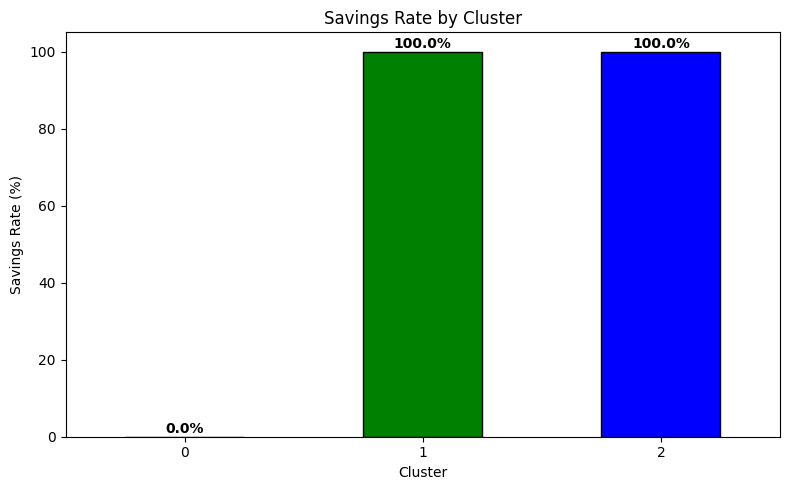

In [ ]:
# savings rate by cluster
plt.figure(figsize=(8, 5))
cluster_savings = df.groupby('cluster')['saved'].mean() * 100
cluster_savings.plot(kind='bar', color=['red', 'green', 'blue'], edgecolor='black')
plt.title('Savings Rate by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Savings Rate (%)')
plt.xticks(rotation=0)
for i, v in enumerate(cluster_savings):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ================================
# SUMMARY AND CONCLUSIONS
# ================================
print('=' * 50)
print('PROJECT SUMMARY')
print('=' * 50)
print(f'\nDataset: Global Findex 2025 - Pakistan')
print(f'Total Samples: {len(df)}')
print(f'Features: {list(X.columns)}')
print(f'\nSavings Rate by Income Quintile:')
for q in sorted(df['inc_q'].unique()):
    rate = df[df['inc_q'] == q]['saved'].mean() * 100
    print(f'  Quintile {int(q)}: {rate:.1f}%')
print(f'\nGradient Boosting Results:')
print(f'  Accuracy:  {accuracy_score(y_test, y_pred):.4f}')
print(f'  Precision: {precision_score(y_test, y_pred):.4f}')
print(f'  Recall:    {recall_score(y_test, y_pred):.4f}')
print(f'  F1-Score:  {f1_score(y_test, y_pred):.4f}')
print(f'  CV Mean F1: {cv_scores.mean():.4f}')
print(f'\nNumber of Clusters (K-Means): 3')

PROJECT SUMMARY

Dataset: Global Findex 2025 - Pakistan
Total Samples: 1880
Features: ['inc_q', 'age', 'female', 'educ', 'urbanicity', 'emp_in', 'inc_educ', 'age_group']

Savings Rate by Income Quintile:
  Quintile 1: 36.2%
  Quintile 2: 56.7%
  Quintile 3: 57.3%
  Quintile 4: 67.7%
  Quintile 5: 73.2%

Gradient Boosting Results:
  Accuracy:  0.8777
  Precision: 0.8363
  Recall:    1.0000
  F1-Score:  0.9109
  CV Mean F1: 0.8994

Number of Clusters (K-Means): 3
